In [5]:
!pip install pandas

# Анализ факторов, влияющих на академическую успеваемость студентов

**Команда №68**

**Участники:**

+ Нгуен Дык Чи Винь — группа БМЭ-242
+ Нгуен Вьет Тханг — группа БМЭ-243
+ Ву Кхой Нгуен — группа БМЭ-244

In [8]:
import pandas as pd
ds = pd.read_csv('indian_engineering_student_placement_added.csv')
ds

,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,hackathons_participated,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,salary_lpa
0,1,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,...,4,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium,14.95
1,2,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,...,4,1,7.1,8,Yes,Medium,Tier 3,Yes,Low,14.91
2,3,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,...,6,3,6.1,2,No,Low,Tier 2,Yes,High,17.73
3,4,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,...,2,2,7.3,7,No,Medium,Tier 1,Yes,Low,14.52
4,5,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,...,2,1,6.0,7,No,Medium,Tier 1,Yes,Medium,15.91
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,Female,IT,10.00,90.4,98.3,0,3.7,75.3,6,...,4,2,7.3,2,No,Medium,Tier 3,Yes,Low,19.35
4996,4997,Male,IT,7.76,74.3,72.6,2,6.3,72.3,4,...,3,2,7.8,6,No,Low,Tier 1,Yes,Low,0.00
4997,4998,Male,IT,7.79,64.0,71.2,2,2.0,63.8,6,...,6,2,6.1,5,Yes,Low,Tier 2,No,Medium,19.13
4998,4999,Female,ECE,8.76,74.3,74.0,0,5.1,72.0,6,...,4,5,9.0,10,No,Medium,Tier 2,Yes,High,16.53


In [9]:
ds.shape

(5000, 24)

## Описание данных
**Тема датасета.**

Прогнозирование трудоустройства студентов инженерных специальностей в Индии.

**Наблюдение в данных.**

Каждый объект (строка) представляет собой данные об одном конкретном студенте (его успеваемость, навыки и статус трудоустройства).

**Источник данных.**

Учебный датасет `indian_engineering_student_placement_added.csv`, использованный в рамках курса по анализу данных.

**Размерность данных.**

- Количество наблюдений: **5000**
- Количество признаков: **24**


In [14]:
ds.dtypes

Student_ID                       int64
gender                          object
branch                          object
cgpa                           float64
tenth_percentage               float64
twelfth_percentage             float64
backlogs                         int64
study_hours_per_day            float64
attendance_percentage          float64
projects_completed               int64
internships_completed            int64
coding_skill_rating              int64
communication_skill_rating       int64
aptitude_skill_rating            int64
hackathons_participated          int64
certifications_count             int64
sleep_hours                    float64
stress_level                     int64
part_time_job                   object
family_income_level             object
city_tier                       object
internet_access                 object
extracurricular_involvement     object
salary_lpa                     float64
dtype: object

In [16]:
ds.head()

,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,hackathons_participated,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,salary_lpa
0,1,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,...,4,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium,14.95
1,2,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,...,4,1,7.1,8,Yes,Medium,Tier 3,Yes,Low,14.91
2,3,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,...,6,3,6.1,2,No,Low,Tier 2,Yes,High,17.73
3,4,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,...,2,2,7.3,7,No,Medium,Tier 1,Yes,Low,14.52
4,5,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,...,2,1,6.0,7,No,Medium,Tier 1,Yes,Medium,15.91


In [18]:
ds.nunique()

Student_ID                     5000
gender                            2
branch                            5
cgpa                            451
tenth_percentage                478
twelfth_percentage              479
backlogs                          6
study_hours_per_day              99
attendance_percentage           414
projects_completed                9
internships_completed             5
coding_skill_rating               5
communication_skill_rating        5
aptitude_skill_rating             5
hackathons_participated           7
certifications_count             10
sleep_hours                      51
stress_level                     10
part_time_job                     2
family_income_level               3
city_tier                         3
internet_access                   2
extracurricular_involvement       3
salary_lpa                     1052
dtype: int64

## Описание признаков

| Название признака | Описание | Формат (Dtype) | Тип данных |
|:---|:---|:---:|:---|
| **Student_ID** | Идентификатор студента | `int64` | Категориальный номинальный |
| **gender** | Пол студента | `object` | Бинарный |
| **branch** | Специализация (ECE, IT, CSE...) | `object` | Категориальный номинальный |
| **cgpa** | Средний балл в университете | `float64` | Количественный непрерывный |
| **tenth_percentage** | % баллов в 10-м классе | `float64` | Количественный непрерывный |
| **twelfth_percentage** | % баллов в 12-м классе | `float64` | Количественный непрерывный |
| **backlogs** | Количество учебных задолженностей | `int64` | Количественный дискретный |
| **study_hours_per_day** | Часов учебы в день | `float64` | Количественный непрерывный |
| **attendance_percentage** | Процент посещаемости | `float64` | Количественный непрерывный |
| **projects_completed** | Кол-во проектов | `int64` | Количественный дискретный |
| **internships_completed** | Кол-во стажировок | `int64` | Количественный дискретный |
| **coding_skill_rating** | Рейтинг кодинга (1-5) | `int64` | Категориальный ранговый |
| **communication_skill_rating** | Рейтинг общения (1-5) | `int64` | Категориальный ранговый |
| **aptitude_skill_rating** | Рейтинг способностей (1-5) | `int64` | Категориальный ранговый |
| **hackathons_participated** | Кол-во участвованных хакатонов | `int64` | Количественный дискретный |
| **certifications_count** | Кол-во сертификатов | `int64` | Количественный дискретный |
| **sleep_hours** | Часов сна | `float64` | Количественный непрерывный |
| **stress_level** | Уровень стресса (1-10) | `int64` | Категориальный ранговый |
| **part_time_job** | Наличие подработки | `object` | Бинарный |
| **family_income_level** | Доход семьи (Low, Medium, High) | `object` | Категориальный ранговый |
| **city_tier** | Категория города (Tier 1, 2, 3) | `object` | Категориальный ранговый |
| **internet_access** | Доступ к интернету | `object` | Бинарный |
| **extracurricular_involvement** | Внеучебная активность (None, Low, Medium, High) | `object` | Категориальный ранговый |
| **salary_lpa** | Зарплата (в лакхах в год) | `float64` | Количественный непрерывный |

In [21]:
ds.isna().sum()

Student_ID                        0
gender                            0
branch                            0
cgpa                              0
tenth_percentage                  0
twelfth_percentage                0
backlogs                          0
study_hours_per_day               0
attendance_percentage             0
projects_completed                0
internships_completed             0
coding_skill_rating               0
communication_skill_rating        0
aptitude_skill_rating             0
hackathons_participated           0
certifications_count              0
sleep_hours                       0
stress_level                      0
part_time_job                     0
family_income_level               0
city_tier                         0
internet_access                   0
extracurricular_involvement    1006
salary_lpa                        0
dtype: int64

In [23]:
(ds.isna().mean() * 100).round(2)

Student_ID                      0.00
gender                          0.00
branch                          0.00
cgpa                            0.00
tenth_percentage                0.00
twelfth_percentage              0.00
backlogs                        0.00
study_hours_per_day             0.00
attendance_percentage           0.00
projects_completed              0.00
internships_completed           0.00
coding_skill_rating             0.00
communication_skill_rating      0.00
aptitude_skill_rating           0.00
hackathons_participated         0.00
certifications_count            0.00
sleep_hours                     0.00
stress_level                    0.00
part_time_job                   0.00
family_income_level             0.00
city_tier                       0.00
internet_access                 0.00
extracurricular_involvement    20.12
salary_lpa                      0.00
dtype: float64

In [25]:
ds['extracurricular_involvement'] = ds['extracurricular_involvement'].fillna('None')

In [27]:
ds.isna().sum()

Student_ID                     0
gender                         0
branch                         0
cgpa                           0
tenth_percentage               0
twelfth_percentage             0
backlogs                       0
study_hours_per_day            0
attendance_percentage          0
projects_completed             0
internships_completed          0
coding_skill_rating            0
communication_skill_rating     0
aptitude_skill_rating          0
hackathons_participated        0
certifications_count           0
sleep_hours                    0
stress_level                   0
part_time_job                  0
family_income_level            0
city_tier                      0
internet_access                0
extracurricular_involvement    0
salary_lpa                     0
dtype: int64

## Пропуски и дубликаты

### Анализ пропусков

В ходе анализа пропущенных значений было выявлено, что большинство признаков не содержит пропусков.
Пропущенные значения присутствуют только в одном категориальном признаке:

- **extracurricular_involvement** — 1006 пропусков (20.12%)

Пропуски означают отсутствием внеучебной активности, поэтому заменем пропуски значением ‘None’.

После выполнения замены пропущенных значений в данных отсутствуют пропуски,
что позволяет использовать датасет для дальнейшего анализа без потери
наблюдений.

In [32]:
ds.duplicated().sum()

0

In [34]:
ds.duplicated('Student_ID').sum()

0

### Анализ дубликатов  

В ходе проверки данных на наличие полных дубликатов наблюдений и дублированных студентов было установлено, что полные дубликаты и дублированные студенты в датасете отсутствуют. Дополнительны действий по очистке данных на данном этапе не потребовалось. 

In [37]:
df = ds.copy()
df

,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,hackathons_participated,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,salary_lpa
0,1,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,...,4,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium,14.95
1,2,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,...,4,1,7.1,8,Yes,Medium,Tier 3,Yes,Low,14.91
2,3,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,...,6,3,6.1,2,No,Low,Tier 2,Yes,High,17.73
3,4,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,...,2,2,7.3,7,No,Medium,Tier 1,Yes,Low,14.52
4,5,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,...,2,1,6.0,7,No,Medium,Tier 1,Yes,Medium,15.91
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,Female,IT,10.00,90.4,98.3,0,3.7,75.3,6,...,4,2,7.3,2,No,Medium,Tier 3,Yes,Low,19.35
4996,4997,Male,IT,7.76,74.3,72.6,2,6.3,72.3,4,...,3,2,7.8,6,No,Low,Tier 1,Yes,Low,0.00
4997,4998,Male,IT,7.79,64.0,71.2,2,2.0,63.8,6,...,6,2,6.1,5,Yes,Low,Tier 2,No,Medium,19.13
4998,4999,Female,ECE,8.76,74.3,74.0,0,5.1,72.0,6,...,4,5,9.0,10,No,Medium,Tier 2,Yes,High,16.53


In [39]:
df.isna().sum().sum(), df.duplicated().sum()

(0, 0)

### Сохранение очищенных данных

После обработки пропущенных значений и проверки данных на наличие полных
дубликатов очищенный датасет был сохранён в новую переменную **df**.

В дальнейшем все этапы анализа и визуализации выполняются с использованием
очищенных данных, что позволяет избежать искажения результатов и соответствует
требованиям задания.


## ВЫБРОСЫ

### Ящики с усами количественных признаков 
(cgpa, tenth_percentage, twelfth_percentage, backlogs, study_hours_per_day, attendance_percentage, projects_completed, internships_completed, hackathons_participated, certifications_count, sleep_hours, salary_lpa)

In [44]:
import seaborn as sns 
import matplotlib.pyplot as plt 

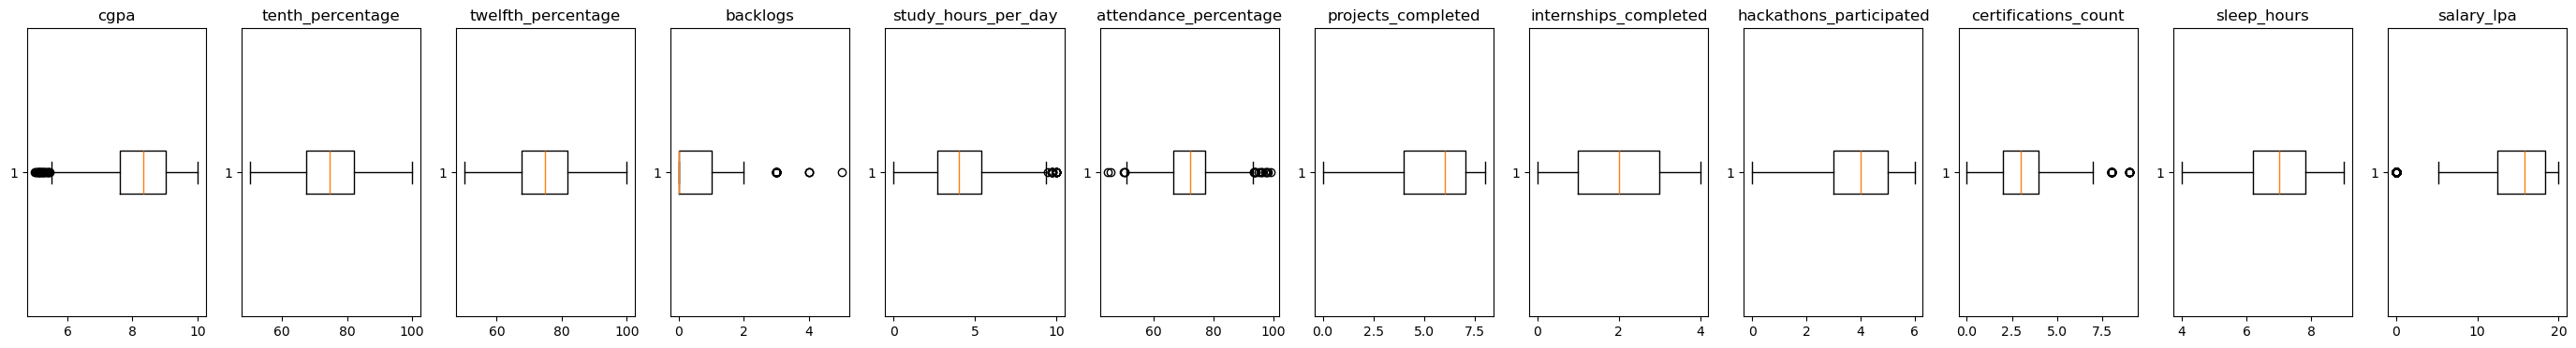

In [45]:
col_num = ['cgpa', 'tenth_percentage', 'twelfth_percentage', 'backlogs', 'study_hours_per_day', 'attendance_percentage', 'projects_completed', 
           'internships_completed', 'hackathons_participated', 'certifications_count', 'sleep_hours', 'salary_lpa']           
fig, ax = plt.subplots(1, 12, figsize=(35, 4))     
for i in range(len(col_num)):                   
    ax[i].set_title(col_num[i])                  
    ax[i].boxplot(df[col_num[i]], vert=False)

### Удаление выбосы

**Удаление выбросов по признакам методом N стандартных отклонений (по таблице df)**

Результаты будут сохранёны в новую переменную **df_clean**.

In [48]:
N=2
cols_to_check = ['cgpa', 'backlogs', 'study_hours_per_day', 'attendance_percentage', 'certifications_count', 'salary_lpa']
df_clean = df.copy()
for col in cols_to_check:
    mean = df_clean[col].mean()  
    std = df_clean[col].std()    
    left = mean - N * std   
    right = mean + N * std  
    df_clean = df_clean[df_clean[col].between (left, right)]
df_clean

,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,hackathons_participated,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,salary_lpa
0,1,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,...,4,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium,14.95
1,2,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,...,4,1,7.1,8,Yes,Medium,Tier 3,Yes,Low,14.91
2,3,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,...,6,3,6.1,2,No,Low,Tier 2,Yes,High,17.73
3,4,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,...,2,2,7.3,7,No,Medium,Tier 1,Yes,Low,14.52
6,7,Male,CE,8.26,81.2,74.8,0,1.8,59.6,4,...,4,4,5.7,8,No,Low,Tier 1,No,High,10.97
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4993,4994,Female,IT,7.90,73.8,67.8,0,2.8,65.1,3,...,2,1,8.1,7,Yes,Medium,Tier 2,Yes,Low,13.65
4994,4995,Male,CSE,10.00,93.2,88.1,0,8.0,81.3,4,...,3,3,6.3,6,No,Medium,Tier 3,Yes,Low,18.39
4995,4996,Female,IT,10.00,90.4,98.3,0,3.7,75.3,6,...,4,2,7.3,2,No,Medium,Tier 3,Yes,Low,19.35
4998,4999,Female,ECE,8.76,74.3,74.0,0,5.1,72.0,6,...,4,5,9.0,10,No,Medium,Tier 2,Yes,High,16.53


**Распределение данных после удаления выбросов (по таблице df_clean):**

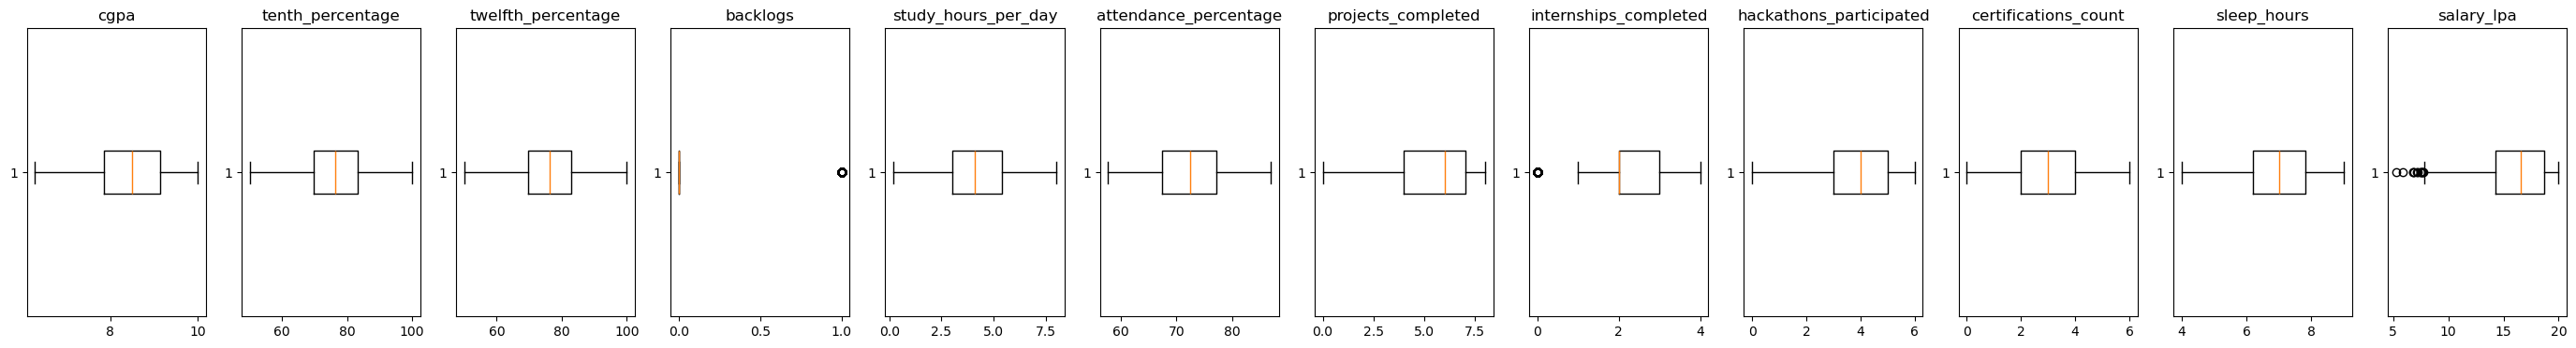

In [52]:
col_num = ['cgpa', 'tenth_percentage', 'twelfth_percentage', 'backlogs', 'study_hours_per_day', 'attendance_percentage', 'projects_completed', 
           'internships_completed', 'hackathons_participated', 'certifications_count', 'sleep_hours', 'salary_lpa']           
fig, ax = plt.subplots(1, 12, figsize=(35, 4))     
for i in range(len(col_num)):                   
    ax[i].set_title(col_num[i])                  
    ax[i].boxplot(df_clean[col_num[i]], vert=False)

In [54]:
cols_to_check = ['backlogs', 'internships_completed', 'salary_lpa']  

df_clean_2 = df_clean.copy()

for col in cols_to_check:
    Q1 = df_clean_2[col].quantile(0.25)  
    Q3 = df_clean_2[col].quantile(0.75) 
    IQR = Q3 - Q1  
    low = Q1 - 1.5 * IQR
    high = Q3 + 1.5 * IQR
    df_clean_2 = df_clean_2[df_clean_2[col].between(low, high)]
df_clean_2

,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,hackathons_participated,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,salary_lpa
0,1,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,...,4,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium,14.95
1,2,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,...,4,1,7.1,8,Yes,Medium,Tier 3,Yes,Low,14.91
2,3,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,...,6,3,6.1,2,No,Low,Tier 2,Yes,High,17.73
6,7,Male,CE,8.26,81.2,74.8,0,1.8,59.6,4,...,4,4,5.7,8,No,Low,Tier 1,No,High,10.97
7,8,Female,IT,7.01,63.9,61.2,0,2.4,64.7,7,...,4,5,4.2,10,No,Medium,Tier 2,Yes,Low,13.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4993,4994,Female,IT,7.90,73.8,67.8,0,2.8,65.1,3,...,2,1,8.1,7,Yes,Medium,Tier 2,Yes,Low,13.65
4994,4995,Male,CSE,10.00,93.2,88.1,0,8.0,81.3,4,...,3,3,6.3,6,No,Medium,Tier 3,Yes,Low,18.39
4995,4996,Female,IT,10.00,90.4,98.3,0,3.7,75.3,6,...,4,2,7.3,2,No,Medium,Tier 3,Yes,Low,19.35
4998,4999,Female,ECE,8.76,74.3,74.0,0,5.1,72.0,6,...,4,5,9.0,10,No,Medium,Tier 2,Yes,High,16.53


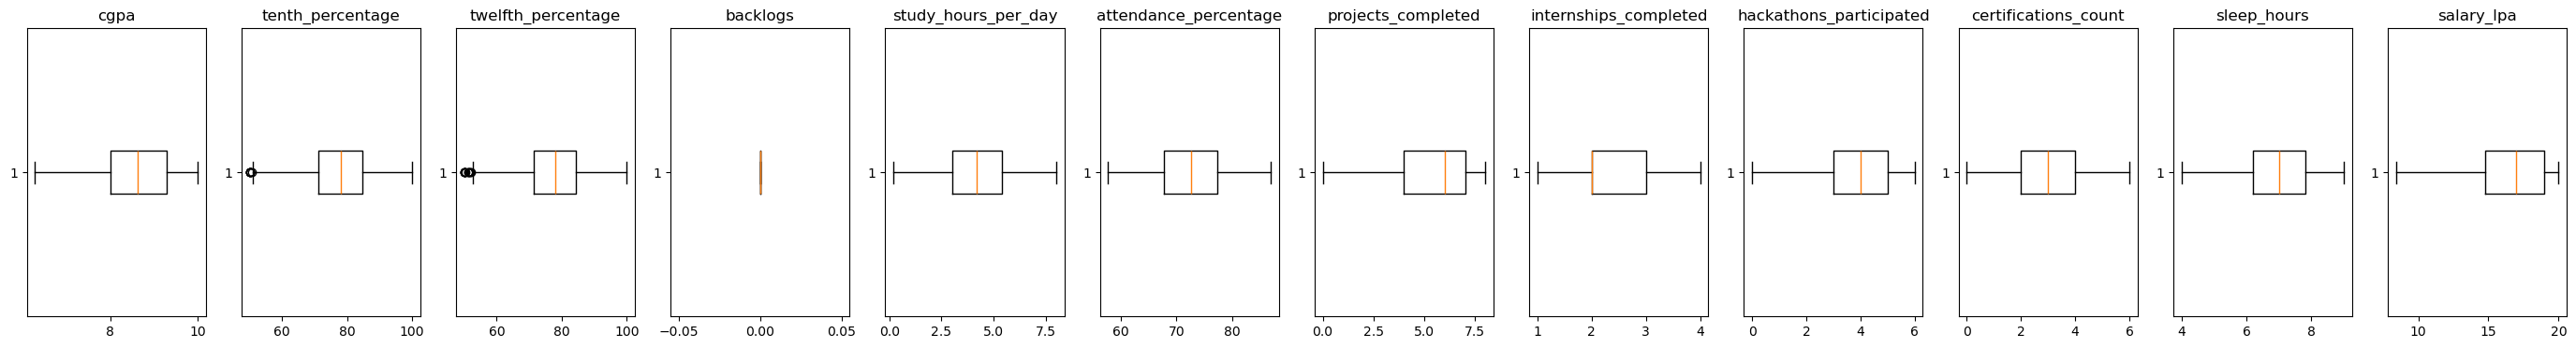

In [55]:
col_num = ['cgpa', 'tenth_percentage', 'twelfth_percentage', 'backlogs', 'study_hours_per_day', 'attendance_percentage', 'projects_completed', 
           'internships_completed', 'hackathons_participated', 'certifications_count', 'sleep_hours', 'salary_lpa']           
fig, ax = plt.subplots(1, 12, figsize=(35, 4))     
for i in range(len(col_num)):                   
    ax[i].set_title(col_num[i])                  
    ax[i].boxplot(df_clean_2[col_num[i]], vert=False)

- Исходное количество строк: 5000
- Количество строк после удаления выбросов: 2779

На очищенной переменной считаются новые значения, в рамках которых появляются новые выбросы, поэтому не можем полностью удалить выбросы.

## ВИЗУАЛИЗАЦИЯ

### Гистограммы количественных признаков
(cgpa, tenth_percentage, twelfth_percentage, backlogs, study_hours_per_day, attendance_percentage, projects_completed, internships_completed, hackathons_participated, certifications_count, sleep_hours, salary_lpa)

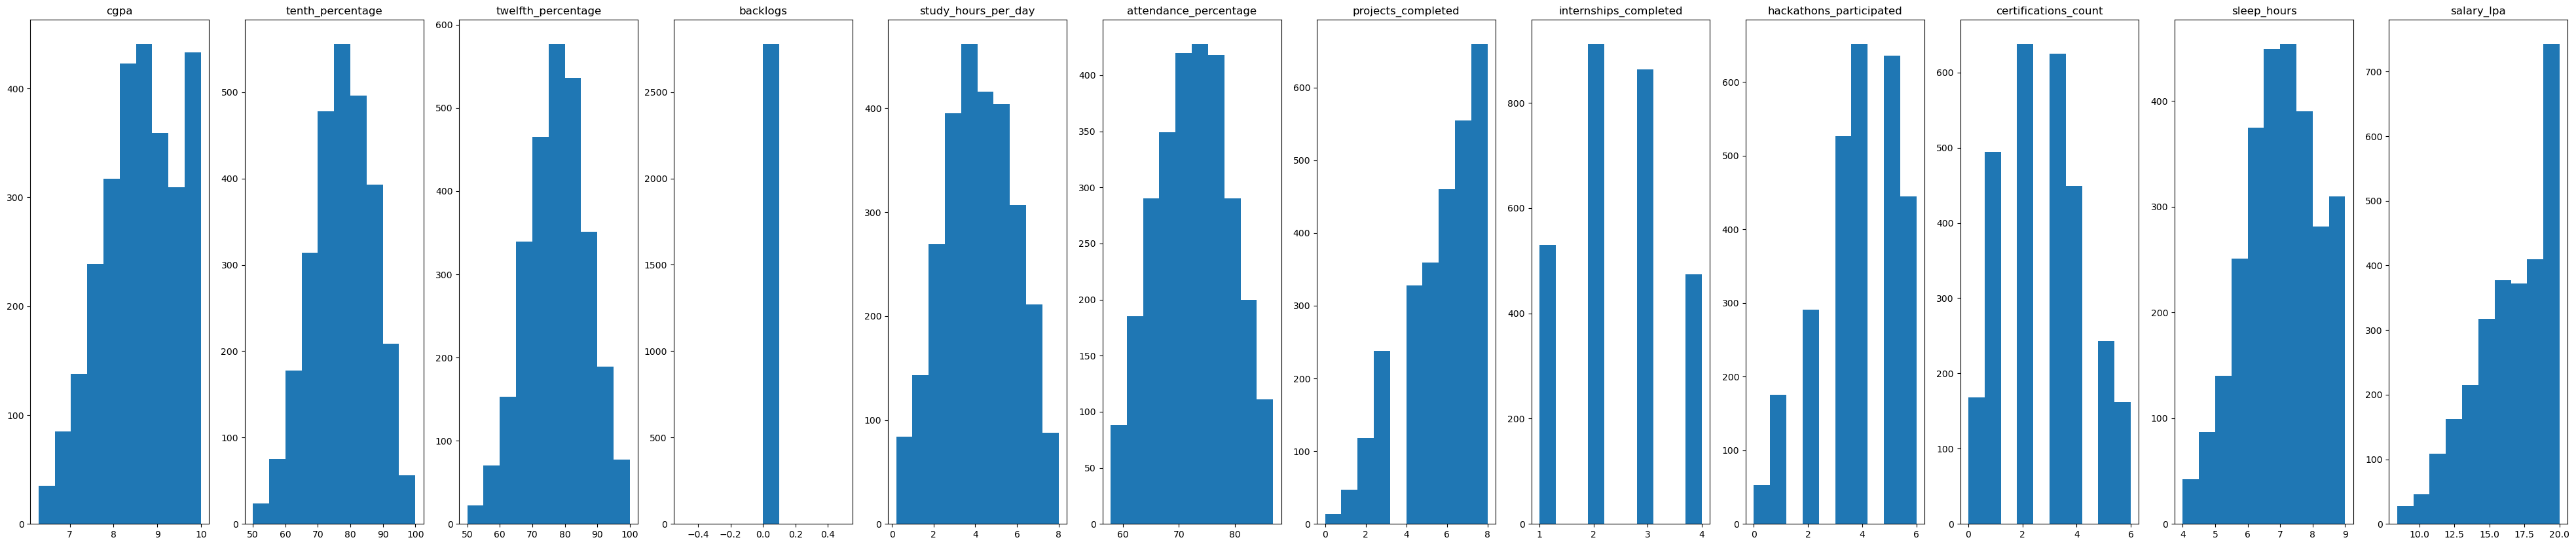

In [62]:
col_num = ['cgpa', 'tenth_percentage', 'twelfth_percentage', 'backlogs', 'study_hours_per_day', 'attendance_percentage', 'projects_completed', 
           'internships_completed', 'hackathons_participated', 'certifications_count', 'sleep_hours', 'salary_lpa']           
fig, ax = plt.subplots(1, 12, figsize=(50, 10))    
for i in range(len(col_num)):                   
    ax[i].set_title(col_num[i])                  
    ax[i].hist(df_clean_2[col_num[i]]);  

* **CGPA:** Распределение имеет левосторонний скос (асимметрия влево). Большинство студентов имеют высокий средний балл, сосредоточенный в диапазоне **8.0–9.5**. Это указывает на то, что в выборке преобладают академически успешные студенты.
* **Tenth & Twelfth Percentage:** Оба распределения близки к нормальному. Пик оценок за 10-й и 12-й классы приходится на интервал **75–85%**, что свидетельствует о стабильной успеваемости большинства студентов еще со школы.
* **Backlogs:** Это дискретное распределение с единственным выраженным пиком в значении **0**. Почти все студенты в данной выборке не имеют академических задолженностей, что подчеркивает их дисциплинированность.
* **Study_Hours_Per_Day:** Распределение похоже на нормальное с пиком в районе **4–5 часов** в день. Большинство студентов придерживаются умеренного графика учебы, в то время как экстремально низкие или высокие значения встречаются редко.
* **Attendance_Percentage:** Распределение сосредоточено в диапазоне **70–85%**. Большинство студентов поддерживают хороший уровень посещаемости, хотя есть и небольшая группа с более низкими показателями.
* **Projects_Completed:** Распределение со смещением вправо. Наибольшее количество студентов выполнили от **6 до 8 проектов**. Это указывает на высокую практическую активность и вовлеченность в проектную деятельность.
* **Internships_Completed:** Распределение является мультимодальным с пиками на значениях **2 и 3 стажировки**. Это говорит о том, что наличие нескольких стажировок является нормой для данной группы студентов.
* **Hackathons_Participated:** Распределение довольно равномерное в центральной части, с наибольшей частотой в районе **3–5 хакатонов**. Студенты активно участвуют в профессиональных соревнованиях.
* **Certifications_Count:** Распределение симметричное, с пиком около **3–4 сертификатов**. Большинство студентов стремятся получить дополнительные профессиональные подтверждения своих навыков.
* **Sleep_Hours:** Распределение довольно сбалансированное, с пиком в районе **7 часов** сна. Это типичный и здоровый показатель для студентов, успешно совмещающих учебу и отдых.
* **Salary_LPA:** Распределение имеет выраженный рост в сторону высоких значений (левосторонний скос). Пик приходится на диапазон **17–20 LPA**. Это свидетельствует о том, что большинство студентов из данной выборки претендуют на высокую заработную плату или уже получают её.

### Столбчатые диаграммы распределения категориальных признаков
(gender, branch, coding_skill_rating, communication_skill_rating, aptitude_skill_rating, stress_level, part_time_job, family_income_level, city_tier, internet_access, extracurricular_involvement)

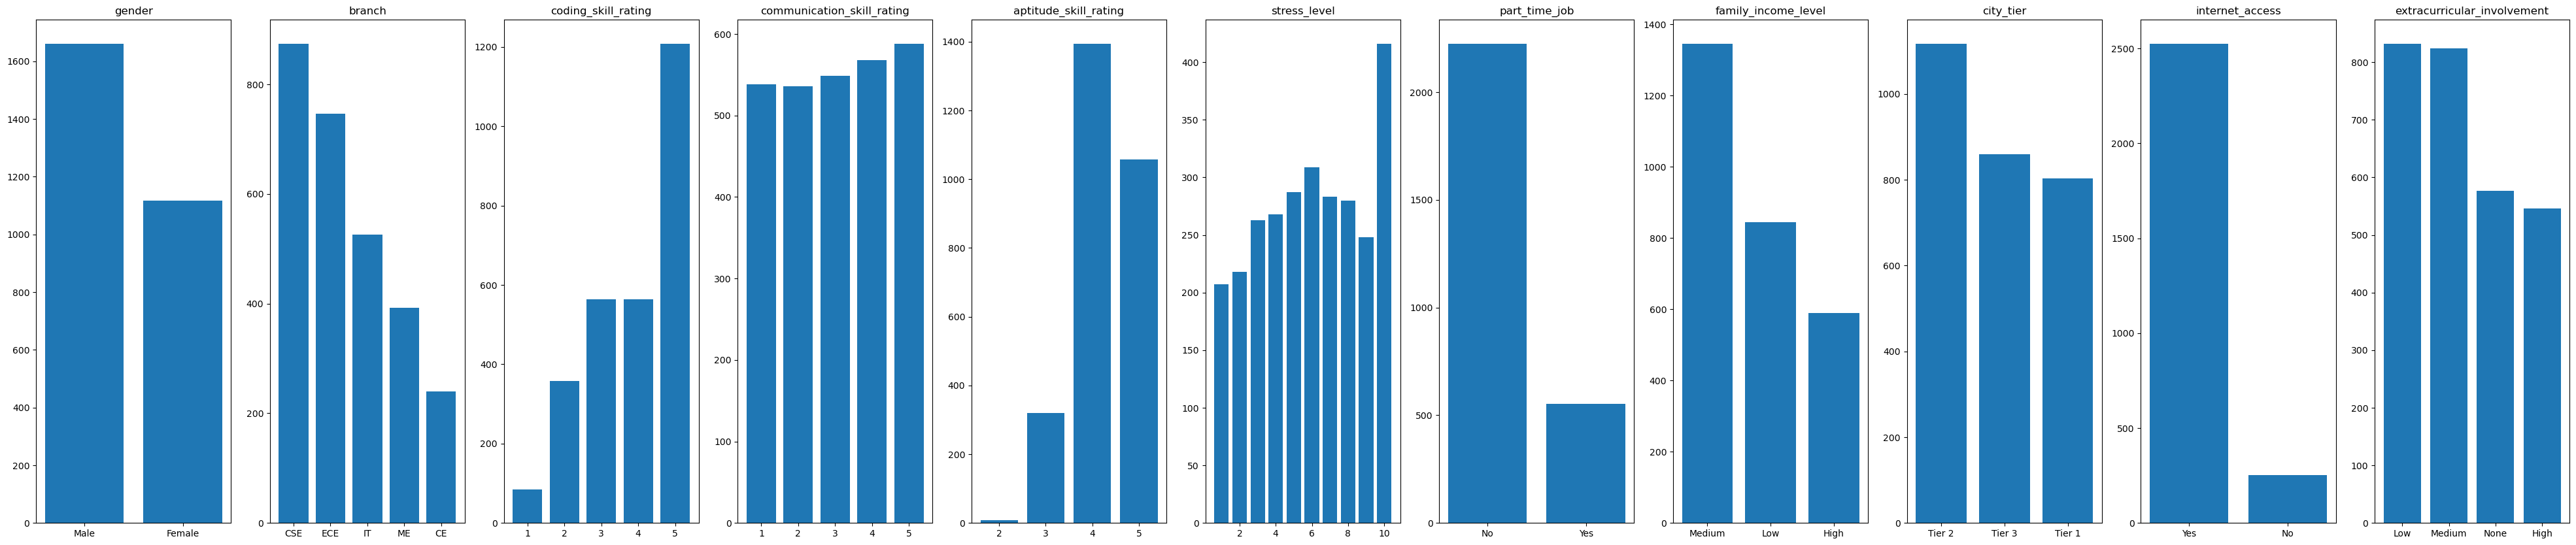

In [65]:
col_cat = ['gender', 'branch', 'coding_skill_rating', 'communication_skill_rating', 'aptitude_skill_rating', 'stress_level', 'part_time_job', 
           'family_income_level', 'city_tier', 'internet_access', 'extracurricular_involvement']           
fig, ax = plt.subplots(1, 11, figsize=(50, 10))   
for i in range(len(col_cat)):                   
    ax[i].set_title(col_cat[i])                 
    freq = df_clean_2[col_cat[i]].value_counts()  
    ax[i].bar(freq.index, freq.values); 

* **Gender:** В данных преобладают мужчины, количество женщин заметно меньше.
* **Branch:** Наибольшее количество студентов обучается на направлении CSE. Меньше всего — на CE.
* **Coding_Skill_Rating:** Большинство студентов оценивают свои навыки на «5». Уровень «1» встречается крайне редко.
* **Communication_Skill_Rating:** Распределение стабильное с небольшим ростом; большинство имеют баллы 4-5.
* **Aptitude_Skill_Rating:** Преобладают студенты с очень высокими показателями (4 и 5).
* **Stress_Level:** Значительная часть студентов отмечает максимальный уровень стресса (10).
* **Part_Time_Job:** Большинство студентов сосредоточены только на учебе и не имеют подработки.
* **Family_Income_Level:** Доминирует средний уровень дохода (Medium). Высокий доход встречается реже всего.
* **City_Tier:** Основная масса студентов — выходцы из городов Tier 2.
* **Internet_Access:** Доступ к интернету есть почти у всех, что типично для современных образовательных выборок.
* **Extracurricular_Involvement:** Большинство вовлечены на низком или среднем уровне, высокая активность проявляется реже.

### Скрипичные графики

**Целевой признак (cgpa)**

### Зависимости средних баллов (cgpa) от количественных признаков

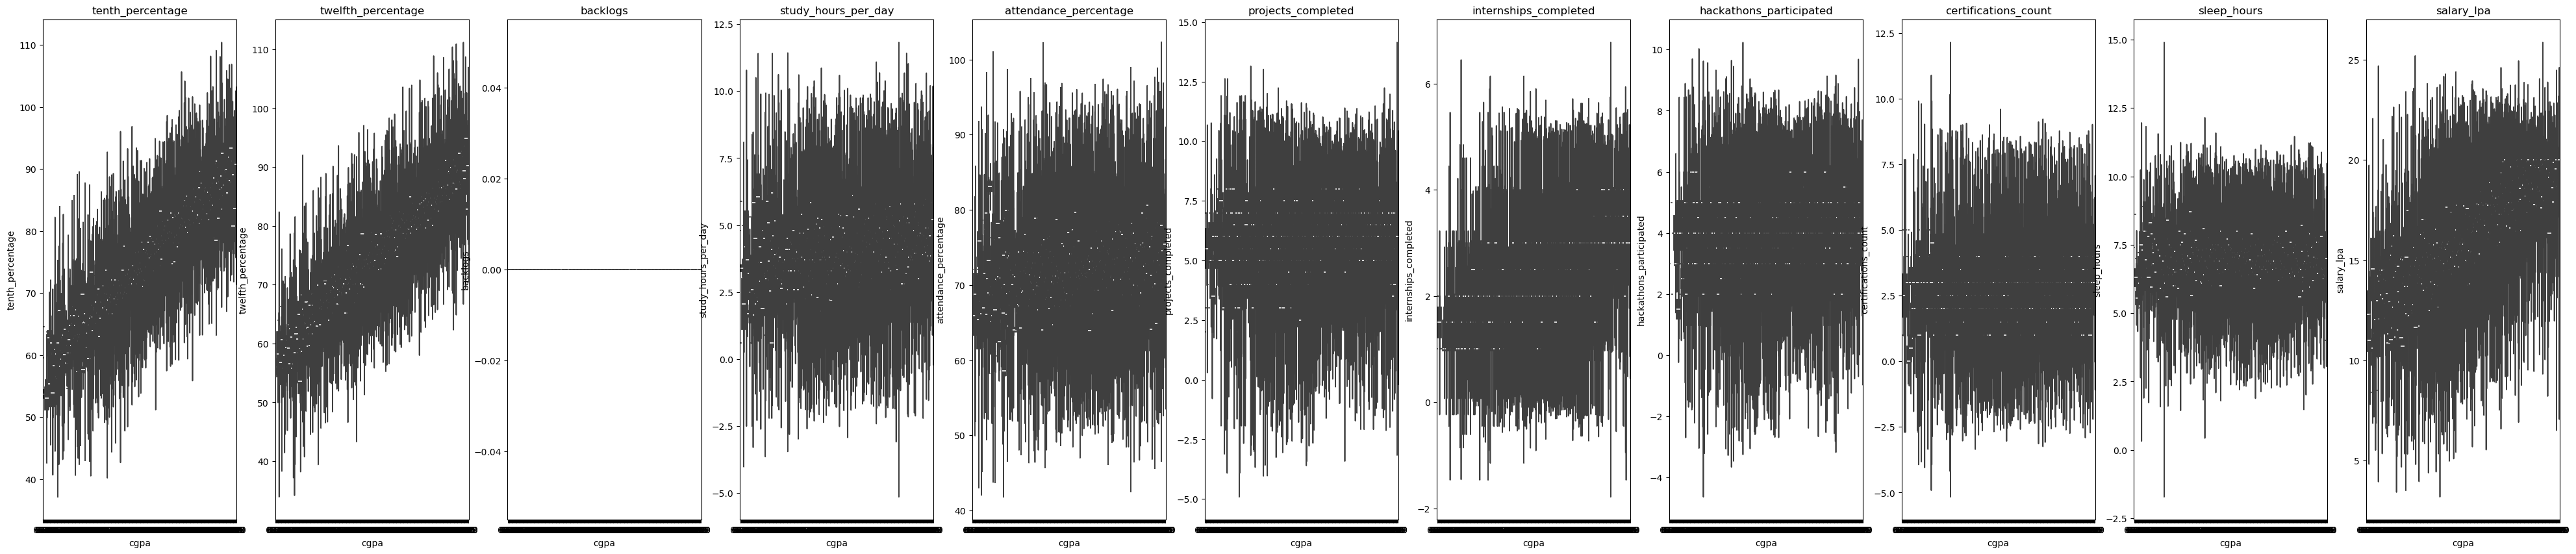

In [72]:
col_num = ['tenth_percentage', 'twelfth_percentage', 'backlogs', 'study_hours_per_day', 'attendance_percentage', 'projects_completed', 
           'internships_completed', 'hackathons_participated', 'certifications_count', 'sleep_hours', 'salary_lpa']

fig, ax = plt.subplots(1, len(col_num), figsize=(50, 10))
for i in range(len(col_num)):
    ax[i].set_title(col_num[i]) 
    sns.violinplot(x='cgpa', y=col_num[i], data=df_clean_2, ax=ax[i])
    ax[i].set_xlabel('cgpa')  
    ax[i].set_ylabel(col_num[i])  

### Зависимости средних баллов (cgpa) от категориальных признаков

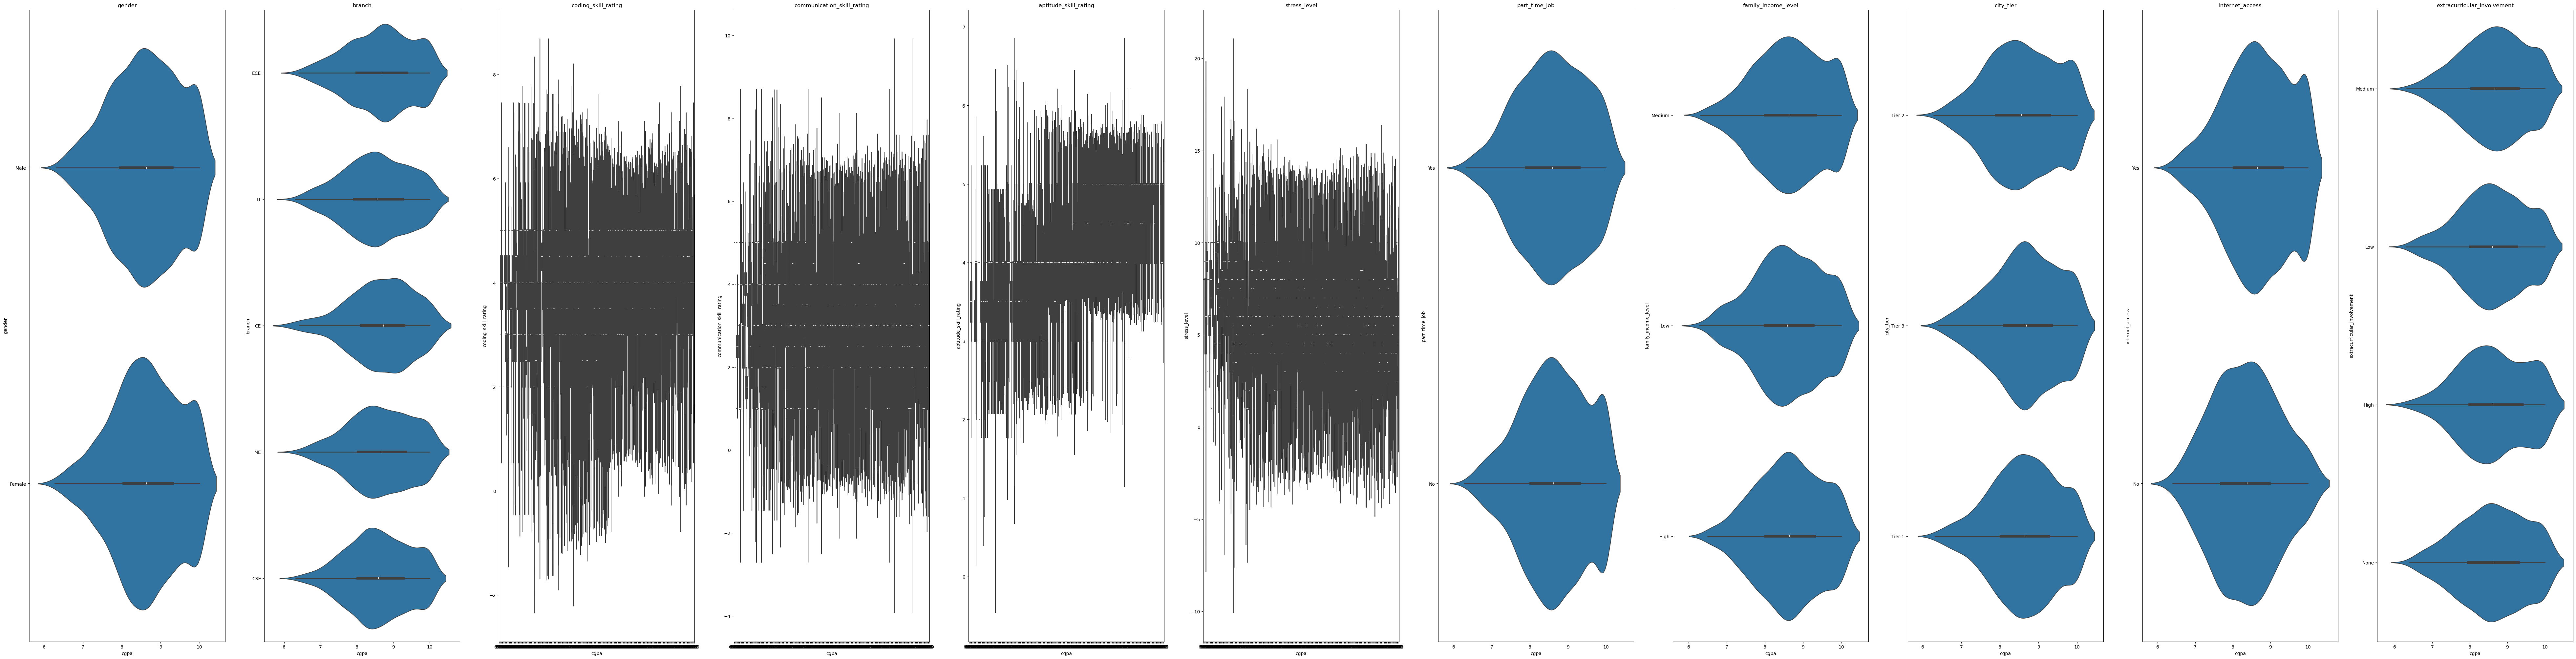

In [100]:
col_cat = ['gender', 'branch', 'coding_skill_rating', 'communication_skill_rating', 'aptitude_skill_rating', 'stress_level', 'part_time_job', 
           'family_income_level', 'city_tier', 'internet_access', 'extracurricular_involvement']

fig, ax = plt.subplots(1, len(col_cat), figsize=(100, 25))
for i in range(len(col_cat)):
    ax[i].set_title(col_cat[i]) 
    sns.violinplot(x='cgpa', y=col_cat[i], data=df_clean_2, ax=ax[i])
    ax[i].set_xlabel('cgpa') 
    ax[i].set_ylabel(col_cat[i])   

* **Gender:** Распределение CGPA среди мужчин и женщин практически идентично. Оба пола имеют схожие медианные значения, что указывает на отсутствие значительного влияния гендерного фактора на успеваемость в данном наборе данных.
* **Branch:** Направление обучения оказывает определенное влияние на CGPA. В некоторых специальностях графики более «вытянуты» в сторону высоких баллов, что может быть связано со спецификой оценки на разных факультетах.
* **Part-time Job:** Студенты, не имеющие подработки (No), демонстрируют более стабильный и высокий CGPA по сравнению с теми, кто работает. Полная концентрация на учебе способствует лучшей успеваемости.
* **Family Income Level:** Уровень дохода семьи положительно коррелирует с академическими успехами. Студенты из семей с более высоким достатком имеют лучшие условия для обучения.
* **City Tier:** Студенты из городов первого уровня (Tier 1) чаще имеют более высокий CGPA по сравнению с жителями городов Tier 2 и Tier 3, что может быть связано с качеством доступных ресурсов.
* **Internet Access:** Наличие доступа к интернету является ключевым фактором. Группа с доступом к сети имеет заметно более высокую медиану CGPA, что подтверждает важность онлайн-ресурсов в образовании.
* **Extracurricular Involvement:** Участие во внеучебной деятельности не мешает учебе. Напротив, активные студенты часто имеют стабильно высокие баллы, что свидетельствует об их умении эффективно управлять временем.

## Описательные статистики

### Целевой признак (cgpa)

In [79]:
df_clean_2['cgpa'].describe()

count    2779.000000
mean        8.623167
std         0.878229
min         6.280000
25%         8.010000
50%         8.630000
75%         9.305000
max        10.000000
Name: cgpa, dtype: float64

* **Среднее значение (mean)** составляет около **8.62**, что отражает общий высокий уровень академической успеваемости студентов в данной выборке.
* **Медиана (50%)** равна **8.63**, что практически совпадает со средним значением. Это указывает на высокую степень симметричности распределения баллов CGPA без значительных перекосов.
* **Межквартильный размах** (от **8.01** до **9.305**) показывает, что 50% студентов имеют оценки в этом диапазоне, что свидетельствует о достаточно плотной концентрации данных вокруг центральных значений.
* **Стандартное отклонение (std)** составляет **0.878**, что говорит о низком разбросе данных. Баллы студентов довольно однородны и находятся близко к среднему значению.
* **Минимальное и максимальное значения** (**6.28** и **10.0** соответственно) показывают полный диапазон оценок. Максимальный балл 10.0 может указывать на наличие отличников, в то время как минимальный балл 6.28 находится не слишком далеко от среднего, что подтверждает отсутствие критических аномалий или экстремальных выбросов.

### Описательные статистики предикторов

In [82]:
df_clean_2[['tenth_percentage', 'twelfth_percentage', 'backlogs', 'study_hours_per_day', 'attendance_percentage', 'projects_completed', 
           'internships_completed', 'hackathons_participated', 'certifications_count', 'sleep_hours', 'salary_lpa']].describe()

,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,hackathons_participated,certifications_count,sleep_hours,salary_lpa
count,2779.000000,2779.000000,2779.0,2779.000000,2779.000000,2779.000000,2779.000000,2779.000000,2779.000000,2779.000000,2779.000000
mean,77.588413,77.698057,0.0,4.200720,72.510687,5.767902,2.460957,3.884851,2.744872,6.978158,16.616240
std,9.409797,9.318616,0.0,1.704441,6.543707,1.937216,0.985590,1.528839,1.567318,1.141763,2.754765
min,50.000000,50.000000,0.0,0.200000,57.800000,0.000000,1.000000,0.000000,0.000000,4.000000,8.410000
25%,71.100000,71.400000,0.0,3.000000,67.700000,4.000000,2.000000,3.000000,2.000000,6.200000,14.750000
50%,78.100000,78.000000,0.0,4.200000,72.600000,6.000000,2.000000,4.000000,3.000000,7.000000,16.970000
75%,84.600000,84.250000,0.0,5.400000,77.300000,7.000000,3.000000,5.000000,4.000000,7.800000,18.995000
max,100.000000,100.000000,0.0,8.000000,86.800000,8.000000,4.000000,6.000000,6.000000,9.000000,20.000000


### Числовые предикторы

* **tenth_percentage & twelfth_percentage**: Средние значения успеваемости в 10-м и 12-м классах практически идентичны и составляют около **77.59%** и **77.70%** соответственно. Медианы (**78.1%** и **78.0%**) близки к средним, что указывает на симметричное распределение. Диапазон оценок варьируется от **50%** до **100%**, отражая разнообразие академической подготовки студентов.
* **backlogs**: Данный признак имеет нулевые значения для всех статистик (mean, std, min, max = **0.0**). Это означает, что в текущей выборке у всех студентов отсутствуют задолженности по предметам.
* **study_hours_per_day**: Студенты учатся в среднем около **4.2 часов** в день, что совпадает с медианой (**4.2**). Межквартильный размах (от **3.0** до **5.4** часов) свидетельствует об умеренной вариативности учебной нагрузки.
* **attendance_percentage**: Средний уровень посещаемости составляет **72.5%**, при этом 50% студентов имеют посещаемость в узком диапазоне от **67.7%** до **77.3%**. Максимальная посещаемость ограничена значением **86.8%**.
* **projects_completed**: В среднем студенты завершают около **5.77** проектов. Медиана равна **6**, что говорит о том, что большинство студентов активно участвуют в проектной деятельности (от **4** до **7** проектов для основной массы).
* **internships_completed**: Студенты проходят в среднем около **2.46** стажировок. Значения распределены в узком диапазоне от **1** до **4**, что указывает на наличие практического опыта у всей выборки.
* **hackathons_participated**: Среднее количество участий в хакатонах составляет почти **4** (**3.88**). Разброс значений от **0** до **6** показывает, что в выборке есть как новички, так и активные участники соревнований.
* **certifications_count**: Студенты имеют в среднем около **2.74** сертификатов. Медиана (**3**) и межквартильный размах (от **2** до **4**) указывают на стабильное стремление студентов к получению дополнительных квалификаций.
* **sleep_hours**: Средняя продолжительность сна составляет около **7 часов** (**6.98**), что соответствует норме. Большинство студентов спят от **6.2** до **7.8** часов в сутки.
* **salary_lpa**: Средняя ожидаемая или текущая зарплата составляет **16.62 LPA**. Низкое стандартное отклонение (**2.75**) и близость медианы (**16.97**) к среднему указывают на отсутствие резких скачков в данных о доходах внутри выборки.

In [86]:
df_clean_2['gender'].value_counts()

gender
Male      1661
Female    1118
Name: count, dtype: int64

In [87]:
df_clean_2['branch'].value_counts()

branch
CSE    874
ECE    746
IT     526
ME     393
CE     240
Name: count, dtype: int64

In [88]:
df_clean_2['coding_skill_rating'].value_counts()

coding_skill_rating
5    1208
4     564
3     564
2     358
1      85
Name: count, dtype: int64

In [89]:
df_clean_2['communication_skill_rating'].value_counts()

communication_skill_rating
5    588
4    568
3    549
1    538
2    536
Name: count, dtype: int64

In [90]:
df_clean_2['aptitude_skill_rating'].value_counts()

aptitude_skill_rating
4    1394
5    1057
3     320
2       8
Name: count, dtype: int64

In [91]:
df_clean_2['stress_level'].value_counts()

stress_level
10    416
6     309
5     287
7     283
8     280
4     268
3     263
9     248
2     218
1     207
Name: count, dtype: int64

In [92]:
df_clean_2['part_time_job'].value_counts()

part_time_job
No     2225
Yes     554
Name: count, dtype: int64

In [93]:
df_clean_2['family_income_level'].value_counts()

family_income_level
Medium    1345
Low        845
High       589
Name: count, dtype: int64

In [94]:
df_clean_2['city_tier'].value_counts()

city_tier
Tier 2    1117
Tier 3     859
Tier 1     803
Name: count, dtype: int64

In [95]:
df_clean_2['internet_access'].value_counts()

internet_access
Yes    2525
No      254
Name: count, dtype: int64

In [96]:
df_clean_2['extracurricular_involvement'].value_counts()

extracurricular_involvement
Low       832
Medium    824
None      577
High      546
Name: count, dtype: int64

### Категориальные предикторы

На основе распределения категориальных признаков можно сделать следующие выводы:

* **Gender**: В выборке преобладают студенты мужского пола (**Male — 1661**), количество студентов женского пола составляет **1118**. Несмотря на численное преимущество мужчин, доля женщин остается значительной, что обеспечивает репрезентативность обеих групп.
* **Branch**: Наибольшее количество студентов обучается на направлении **CSE (874)**, за которым следуют **ECE (746)** и **IT (526)**. Направления **ME (393)** и **CE (240)** представлены в меньшей степени, что отражает популярность ИТ-специальностей в данной выборке.
* **Coding_Skill_Rating**: Большинство студентов оценивают свои навыки программирования на высший балл (**5 — 1208 человек**). Группы с рейтингами **4 (564)** и **3 (564)** равны, а студентов с низким уровнем навыков (**1 — 85**) крайне мало, что говорит о высоком уровне технической подготовки учащихся.
* **Communication_Skill_Rating**: Распределение навыков общения достаточно равномерное по всем уровням (от **536** до **588** человек на категорию). Это указывает на разнообразие коммуникативных способностей среди студентов без явного преобладания одной группы.
* **Aptitude_Skill_Rating**: Подавляющее большинство студентов имеют высокий уровень способностей, оцениваемый на **4 (1394)** и **5 (1057)** баллов. Низкие оценки встречаются крайне редко (**2 — 8**), что свидетельствует о сильных аналитических навыках у большинства участников выборки.
* **Stress_Level**: Уровень стресса распределен по шкале от 1 до 10. Наиболее многочисленной является группа с экстремально высоким уровнем стресса (**10 — 416 человек**), в то время как остальные уровни распределены относительно равномерно, что указывает на значительную учебную нагрузку.
* **Part_time_Job**: Подавляющее большинство студентов не имеют подработки (**No — 2225**), в то время как лишь небольшая часть (**Yes — 554**) совмещает работу с учебой. Это позволяет предположить, что основное время учащихся сфокусировано на образовательном процессе.
* **Family_Income_Level**: Наиболее распространенным является средний уровень дохода семьи (**Medium — 1345**). Студенты из семей с низким доходом (**Low — 845**) встречаются чаще, чем из семей с высоким доходом (**High — 589**).
* **City_Tier**: Большинство студентов проживают в городах второго уровня (**Tier 2 — 1117**). Количество студентов из городов **Tier 3 (859)** и **Tier 1 (803)** сопоставимо, что говорит о широком географическом охвате выборки.
* **Internet_Access**: Подавляющее большинство студентов имеют доступ к интернету (**Yes — 2525**), и лишь малая часть лишена этой возможности (**No — 254**). Это свидетельствует о доступности цифровых ресурсов для большинства обучающихся.
* **Extracurricular_Involvement**: Уровень участия во внеучебной деятельности распределен неоднородно: преобладают группы с низким (**Low — 832**) и средним (**Medium — 824**) уровнями вовлеченности. Значительная часть студентов вообще не участвует в активностях (**None — 577**), а высокая вовлеченность (**High — 546**) встречается реже всего.

## Перекодирование данных

- Целевой признак: **Exam_Score**.  
- **Категориальные признаки**: gender, branch, coding_skill_rating, communication_skill_rating, aptitude_skill_rating, stress_level, part_time_job, family_income_level, city_tier, internet_access, extracurricular_involvement
- **Категориальные бинарные признаки**: gender, part_time_job, internet_access

### One-Hot Encoding для категориальных бинарных признаков

In [115]:
df_encoded = pd.get_dummies(df_clean_2, columns = ['gender', 'part_time_job', 'internet_access'], dtype=int)
df_encoded

,Student_ID,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,...,family_income_level,city_tier,extracurricular_involvement,salary_lpa,gender_Female,gender_Male,part_time_job_No,part_time_job_Yes,internet_access_No,internet_access_Yes
0,1,ECE,8.74,74.0,75.0,0,3.8,71.1,7,3,...,Medium,Tier 2,Medium,14.95,0,1,0,1,0,1
1,2,ECE,7.80,75.3,69.7,0,6.3,69.5,5,1,...,Medium,Tier 3,Low,14.91,1,0,0,1,0,1
2,3,IT,6.95,62.8,68.3,0,1.5,62.5,8,2,...,Low,Tier 2,High,17.73,1,0,1,0,0,1
6,7,CE,8.26,81.2,74.8,0,1.8,59.6,4,1,...,Low,Tier 1,High,10.97,0,1,1,0,1,0
7,8,IT,7.01,63.9,61.2,0,2.4,64.7,7,1,...,Medium,Tier 2,Low,13.41,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4993,4994,IT,7.90,73.8,67.8,0,2.8,65.1,3,2,...,Medium,Tier 2,Low,13.65,1,0,0,1,0,1
4994,4995,CSE,10.00,93.2,88.1,0,8.0,81.3,4,4,...,Medium,Tier 3,Low,18.39,0,1,1,0,0,1
4995,4996,IT,10.00,90.4,98.3,0,3.7,75.3,6,3,...,Medium,Tier 3,Low,19.35,1,0,1,0,0,1
4998,4999,ECE,8.76,74.3,74.0,0,5.1,72.0,6,4,...,Medium,Tier 2,High,16.53,1,0,1,0,0,1


### Label Encoding для категориальных признаков

In [118]:
from sklearn.preprocessing import LabelEncoder
col_cat = ['gender', 'branch', 'coding_skill_rating', 'communication_skill_rating', 'aptitude_skill_rating', 'stress_level', 
           'part_time_job', 'family_income_level', 'city_tier', 'internet_access', 'extracurricular_involvement']
for col in col_cat:
  df_clean_2[f'{col}_encoded'] = LabelEncoder().fit_transform(df_clean_2[col])
df_clean_2

,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,branch_encoded,coding_skill_rating_encoded,communication_skill_rating_encoded,aptitude_skill_rating_encoded,stress_level_encoded,part_time_job_encoded,family_income_level_encoded,city_tier_encoded,internet_access_encoded,extracurricular_involvement_encoded
0,1,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,...,2,3,1,3,7,1,2,1,1,2
1,2,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,...,2,2,3,1,7,1,2,2,1,1
2,3,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,...,3,4,0,2,1,0,1,1,1,0
6,7,Male,CE,8.26,81.2,74.8,0,1.8,59.6,4,...,0,2,0,1,7,0,1,0,0,0
7,8,Female,IT,7.01,63.9,61.2,0,2.4,64.7,7,...,3,3,0,2,9,0,2,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4993,4994,Female,IT,7.90,73.8,67.8,0,2.8,65.1,3,...,3,1,3,3,6,1,2,1,1,1
4994,4995,Male,CSE,10.00,93.2,88.1,0,8.0,81.3,4,...,1,2,1,3,5,0,2,2,1,1
4995,4996,Female,IT,10.00,90.4,98.3,0,3.7,75.3,6,...,3,3,3,3,1,0,2,2,1,1
4998,4999,Female,ECE,8.76,74.3,74.0,0,5.1,72.0,6,...,2,3,0,2,9,0,2,1,1,0
